### Import

In [1]:
import os
import gc
import time
import pickle 
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt

from typing import Dict
from typing import Callable
from plot_metric.functions import BinaryClassification

from sklearn.metrics import auc
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.isotonic import IsotonicRegression

from aequitas.bias import Bias
from aequitas.group import Group
from aequitas.plotting import Plot
from aequitas.fairness import Fairness

from pynvml import *
import GPUtil
from threading import Thread

import torch
import torch.nn as nn

from torch.optim import AdamW
import torch.nn.functional as F

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as t_Dataset
from torch.utils.data.sampler import WeightedRandomSampler

from torch.nn.utils.rnn import pad_packed_sequence
from torch.nn.utils.rnn import pack_padded_sequence

import evaluate
import datasets

from datasets import DatasetDict
from datasets import load_dataset
from datasets import list_metrics
from datasets import load_from_disk
from datasets import Dataset as d_Dataset

from transformers import get_scheduler
from transformers import get_linear_schedule_with_warmup

from transformers import BertModel
from transformers import AutoModel
from transformers import AutoTokenizer
from transformers import DataCollatorWithPadding
from transformers import AutoModelForSequenceClassification

from captum.attr import visualization as viz
from captum.attr import LayerConductance
from captum.attr import LayerIntegratedGradients

from bertviz import head_view
from bertviz import model_view

from transformers import utils
utils.logging.set_verbosity_error() 
pd.set_option('display.max_columns', 500)

### General parameters

In [2]:
race_path = "Extraction/MIMICIV/Data/csvExtract/"
path_data = "../Data/EHR/"
path_data_rep = "../Data/Representations/"
path_cohort   = "../Data/Cohorts/"
path_checkpoints = "../checkpoints/Fusion/"

### Read Cohorts Splits

In [3]:
with open(path_cohort + "short_icustays", "rb") as fp:   
    short_icustays = pickle.load(fp)
    
with open(path_cohort + "train_icustays", "rb") as fp:   
    train_icustays = pickle.load(fp)
    
with open(path_cohort + "valid_icustays", "rb") as fp:   
    valid_icustays = pickle.load(fp)
    
with open(path_cohort + "test_icustays" , "rb") as fp:   
    test_icustays = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_text_image", "rb") as fp:   
    icustays_ehr_text_image = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_text", "rb") as fp:   
    icustays_ehr_text = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_only", "rb") as fp:   
    icustays_ehr_only = pickle.load(fp)
    
with open(path_cohort + "note_ids_24h", "rb") as fp:   
    note_ids_24h = pickle.load(fp)
    
with open(path_cohort + "image_ids_24h", "rb") as fp:   
    image_ids_24h = pickle.load(fp)

### EHR

In [4]:
df_ehr = pd.read_csv(path_data_rep + 'EHR/ehr_lstm_representation.csv', low_memory=False, index_col=False)
df_ehr = df_ehr.drop(columns=['ICU_FLAG', 'LSTM_LABEL', 'label', 'prediction',
                              'all_matching', 'LSTM_PREDICT_LABEL'])
df_ehr = df_ehr.rename(columns={"LSTM_PREDICT_PROB": "ehr_probability"})
df_ehr.head(3)

In [5]:
print(df_ehr.stay_id.nunique())
print(df_ehr.shape)

71343
(71343, 262)


### Comorbidities

In [6]:
df_comorbidity = pd.read_csv(path_data_rep + 'COMORBIDITY/comorbidity_autoenc_representation.csv', index_col=False)
df_comorbidity = df_comorbidity.drop(columns=['icu_expire_flag'])
df_comorbidity = df_comorbidity.rename(columns={"LSTM_PREDICT_PROB": "comor_probability"})
df_comorbidity.head(3)

In [7]:
print(df_comorbidity.stay_id.nunique())
print(df_comorbidity.shape)

71343
(71343, 66)


### Notes

In [8]:
df_notes = pd.read_csv(path_data_rep + 'TEXT/text_llm_representation.csv', low_memory=False, index_col=False)
df_notes = df_notes.drop(columns=['ICU_FLAG', 'race', 'age', 'gender', 'True_Label', 'icu_expire_flag'])
df_notes = df_notes.rename(columns={"Predicted_Probability": "llm_probability"})
df_notes.head(3)

In [9]:
print(df_notes.stay_id.nunique())
print(df_notes.shape)

55578
(295711, 771)


In [10]:
df_patient_notes = pd.read_csv(path_data_rep + 'TEXT/text_lstm_representation.csv', low_memory=False, index_col=False)
df_patient_notes = df_patient_notes.drop(columns=['ICU_FLAG', 'race', 'age', 'gender', 'label', 'icu_expire_flag',
                                                  'all_matching', 'LSTM_PREDICT_LABEL', 'LSTM_LABEL', 'LSTM_PREDICT_PROB'])
df_patient_notes = df_patient_notes.rename(columns={"prediction": "llm_lstm_probability"})
df_patient_notes.head(3)

In [11]:
print(df_patient_notes.stay_id.nunique())
print(df_patient_notes.shape)

51635
(51635, 258)


### Filter Text and Images of First 24 Hours

In [13]:
df_notes  = df_notes[df_notes.note_id.isin(note_ids_24h)]

### Select Patients with All 4 Modalities

In [14]:
df_ehr = df_ehr[df_ehr.stay_id.isin(df_notes.stay_id.unique())]
df_comorbidity = df_comorbidity[df_comorbidity.stay_id.isin(df_notes.stay_id.unique())]
df_notes = df_notes[df_notes.stay_id.isin(df_notes.stay_id.unique())]
df_patient_notes = df_patient_notes[df_patient_notes.stay_id.isin(df_notes.stay_id.unique())]

df_ehr = df_ehr.reset_index(drop=True)
df_comorbidity = df_comorbidity.reset_index(drop=True)
df_notes = df_notes.reset_index(drop=True)
df_patient_notes = df_patient_notes.reset_index(drop=True)

In [15]:
print("***** EHR *****")
print(df_ehr.stay_id.nunique())
print(df_ehr.shape)
print("***** Comorbidity *****")
print(df_comorbidity.stay_id.nunique())
print(df_comorbidity.shape)
print("***** TEXT *****")
print(df_notes.stay_id.nunique())
print(df_notes.shape)
print("***** TEXT *****")
print(df_patient_notes.stay_id.nunique())
print(df_patient_notes.shape)

***** EHR *****
51635
(51635, 262)
***** Comorbidity *****
51635
(51635, 66)
***** TEXT *****
51635
(110409, 771)
***** TEXT *****
51635
(51635, 258)


### Represent each Patients with unique Note & Image Vector

In [17]:
def aggregate_patient_notes(df, approach='mean'):

    if approach == 'mean':
        result_df = df.groupby(['stay_id', 'note_id']).mean().reset_index()
        result_df = result_df.groupby('stay_id').mean().reset_index()
    elif approach == 'max':
        result_df = df.groupby(['stay_id', 'note_id']).max().reset_index()
        result_df = result_df.groupby('stay_id').max().reset_index()
    elif approach == 'max_mean':
        result_df = df.groupby(['stay_id', 'note_id']).max().reset_index()
        result_df = result_df.groupby('stay_id').mean().reset_index()
    else:
        raise ValueError("Invalid approach. Use 'mean' or 'max' or 'max_mean'.")
    
    return result_df

In [18]:
df_notes = aggregate_patient_notes(df_notes, approach='max_mean')

<ipython-input>:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  result_df = result_df.groupby('stay_id').mean().reset_index()


In [18]:
print("***** TEXT *****")
print(df_notes.stay_id.nunique())
print(df_notes.shape)

***** TEXT *****
51635
(51635, 770)


### Spliting Train - Validation - Test

In [19]:
label = 'icu_expire_flag'

In [20]:
ehr_train_df = df_ehr[df_ehr.stay_id.isin(train_icustays)]
ehr_valid_df = df_ehr[df_ehr.stay_id.isin(valid_icustays)]
ehr_test_df  = df_ehr[df_ehr.stay_id.isin(test_icustays)]

comor_train_df = df_comorbidity[df_comorbidity.stay_id.isin(train_icustays)]
comor_valid_df = df_comorbidity[df_comorbidity.stay_id.isin(valid_icustays)]
comor_test_df  = df_comorbidity[df_comorbidity.stay_id.isin(test_icustays)]

note_train_df = df_notes[df_notes.stay_id.isin(train_icustays)]
note_valid_df = df_notes[df_notes.stay_id.isin(valid_icustays)]
note_test_df  = df_notes[df_notes.stay_id.isin(test_icustays)]

note_patient_train_df = df_patient_notes[df_patient_notes.stay_id.isin(train_icustays)]
note_patient_valid_df = df_patient_notes[df_patient_notes.stay_id.isin(valid_icustays)]
note_patient_test_df  = df_patient_notes[df_patient_notes.stay_id.isin(test_icustays)]

In [21]:
ehr_train_df = ehr_train_df.sort_values(by=['stay_id']).reset_index(drop=True)
ehr_valid_df = ehr_valid_df.sort_values(by=['stay_id']).reset_index(drop=True)
ehr_test_df  = ehr_test_df.sort_values( by=['stay_id']).reset_index(drop=True)

comor_train_df = comor_train_df.sort_values(by=['stay_id']).reset_index(drop=True)
comor_valid_df = comor_valid_df.sort_values(by=['stay_id']).reset_index(drop=True)
comor_test_df  = comor_test_df.sort_values( by=['stay_id']).reset_index(drop=True)

note_train_df = note_train_df.sort_values(by=['stay_id']).reset_index(drop=True)
note_valid_df = note_valid_df.sort_values(by=['stay_id']).reset_index(drop=True)
note_test_df  = note_test_df.sort_values( by=['stay_id']).reset_index(drop=True)

note_patient_train_df = note_patient_train_df.sort_values(by=['stay_id']).reset_index(drop=True)
note_patient_valid_df = note_patient_valid_df.sort_values(by=['stay_id']).reset_index(drop=True)
note_patient_test_df  = note_patient_test_df.sort_values( by=['stay_id']).reset_index(drop=True)

In [22]:
gc.collect()

80

### Select Relevant Columns

In [23]:
ehr_encoding_dim = 256
ehr_embeds = [f'embeded_dim{i+1}' for i in range(ehr_encoding_dim)]

ehr_columns = ['gender', 'age', 'race', 'ehr_probability']
ehr_columns.extend(ehr_embeds)

comor_encoding_dim = 64
comorbidity_columns = [f'embeded_dim{i+1}' for i in range(comor_encoding_dim)]
comorbidity_columns.extend(['comor_probability'])

note_encoding_dim = 768
note_columns = [f'embeded_dim{i+1}' for i in range(note_encoding_dim)]
note_columns.extend(['llm_probability'])

note_patient_encoding_dim = 256
note_patient_columns = [f'embeded_dim{i+1}' for i in range(note_patient_encoding_dim)]
note_patient_columns.extend(['llm_lstm_probability'])

### Prepare Test Result Frame

In [24]:
def result_frame(data, label):
        
    result = data.groupby(['stay_id'])[['stay_id', 'gender', 'age', 'race',  label]].head(1).copy()
    
    result['ICU_FLAG'] = np.nan
    result.loc[result['icu_expire_flag'] == 0, 'ICU_FLAG'] = 'Survived'
    result.loc[result['icu_expire_flag'] == 1, 'ICU_FLAG'] = 'Dead'
    
    return result

In [25]:
train_result = result_frame(ehr_train_df, label)
valid_result = result_frame(ehr_valid_df, label)
test_result  = result_frame(ehr_test_df , label)

train_result = train_result.reset_index(drop=True)
valid_result = valid_result.reset_index(drop=True)
test_result  = test_result.reset_index(drop=True)

### Normalization

In [26]:
norm_cols = ['gender', 'age', 'race']

In [27]:
def Normalizing(train_df, valid_df, test_df, norm_cols):
        
    train_val = train_df[norm_cols]
    valid_val = valid_df[norm_cols]
    test_val  = test_df[norm_cols]

    scaler = MinMaxScaler().fit(train_val.values)

    train_normalized = scaler.transform(train_val.values)
    valid_normalized = scaler.transform(valid_val.values)
    test_normalized  = scaler.transform(test_val.values)

    train_df[norm_cols] = train_normalized
    valid_df[norm_cols] = valid_normalized
    test_df[norm_cols]  = test_normalized
    
    return train_df, valid_df, test_df

In [28]:
ehr_train_df, ehr_valid_df, ehr_test_df = Normalizing(ehr_train_df, 
                                                      ehr_valid_df, 
                                                      ehr_test_df,  
                                                      norm_cols)

### EHR Data Preparation

In [29]:
def ehr_data_ready(train_df, valid_df, test_df, columns, label):
    
    train_data = train_df.groupby(['stay_id'])
    valid_data = valid_df.groupby(['stay_id'])
    test_data  = test_df.groupby(['stay_id'])
    
    X_train = []
    y_train = []
    id_train = []
    for icu_id, frame in train_data:
        X_train.append(frame[columns].values)
        y_train.append(frame.iloc[0][label])
        id_train.append(icu_id)
                
    X_valid = []
    y_valid = []
    id_valid = []
    for icu_id, frame in valid_data:
        X_valid.append(frame[columns].values)
        y_valid.append(frame.iloc[0][label])
        id_valid.append(icu_id)
        
    X_test = []
    y_test = []
    id_test = []
    for icu_id, frame in test_data:
        X_test.append(frame[columns].values)
        y_test.append(frame.iloc[0][label])
        id_test.append(icu_id)
        
    y_train = np.array(y_train)
    y_valid = np.array(y_valid)
    y_test  = np.array(y_test)
        
    pos_tr = y_train[y_train == 1]
    neg_tr = y_train[y_train == 0]
    print('Train= Positive - Negative: ', len(pos_tr), len(neg_tr))
    
    pos_vl = y_valid[y_valid == 1]
    neg_vl = y_valid[y_valid == 0]
    print('Valid= Positive - Negative: ', len(pos_vl), len(neg_vl))
    
    pos_ts = y_test[y_test == 1]
    neg_ts = y_test[y_test == 0]
    print('Test = Positive - Negative: ', len(pos_ts), len(neg_ts))
    
    return X_train, y_train, id_train, X_valid, y_valid, id_valid, X_test, y_test, id_test

In [30]:
X_train, y_train, id_train, X_valid, y_valid, id_valid, X_test, y_test, id_test = ehr_data_ready(ehr_train_df, 
                                                                                                 ehr_valid_df, 
                                                                                                 ehr_test_df, 
                                                                                                 ehr_columns, 
                                                                                                 label)

<ipython-input>:10: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in train_data:
<ipython-input>:18: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in valid_data:
<ipython-input>:26: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in test_data:


Train= Positive - Negative:  3099 35941
Valid= Positive - Negative:  263 3406
Test = Positive - Negative:  655 8271


In [31]:
def data_ready(data_train_df, data_valid_df, data_test_df):
    
    train_data = data_train_df.groupby(['stay_id'])
    valid_data = data_valid_df.groupby(['stay_id'])
    test_data  = data_test_df.groupby(['stay_id'])
    
    X_train_data  = []
    id_train_data = []
    for icu_id, frame in train_data:
        X_train_data.append(frame.drop(columns='stay_id').values)
        id_train_data.append(icu_id)
        
    X_valid_data  = []
    id_valid_data = []
    for icu_id, frame in valid_data:
        X_valid_data.append(frame.drop(columns='stay_id').values)
        id_valid_data.append(icu_id)
        
    X_test_data  = []
    id_test_data = []
    for icu_id, frame in test_data:
        X_test_data.append(frame.drop(columns='stay_id').values)
        id_test_data.append(icu_id)
        
    return X_train_data, id_train_data, X_valid_data, id_valid_data, X_test_data, id_test_data

In [32]:
X_train_com, id_train_com, X_valid_com, id_valid_com, X_test_com, id_test_com = data_ready(comor_train_df, 
                                                                                           comor_valid_df, 
                                                                                           comor_test_df)

<ipython-input>:9: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in train_data:
<ipython-input>:15: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in valid_data:
<ipython-input>:21: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in test_data:


In [33]:
X_train_note, id_train_note, X_valid_note, id_valid_note, X_test_note, id_test_note = data_ready(note_train_df, 
                                                                                                 note_valid_df, 
                                                                                                 note_test_df)

X_train_note_lstm, id_train_note_lstm, X_valid_note_lstm, id_valid_note_lstm, X_test_note_lstm, id_test_note_lstm = data_ready(note_patient_train_df, 
                                                                                                                               note_patient_valid_df, 
                                                                                                                               note_patient_test_df)

<ipython-input>:9: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in train_data:
<ipython-input>:15: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in valid_data:
<ipython-input>:21: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in test_data:
<ipython-input>:9: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't s

### Plots

In [34]:
def plot_losses(train_losses, valid_losses):
    
    fig = plt.figure(figsize=(10, 5))

    plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Training Loss'  , linewidth=2, markersize=5)
    plt.plot(range(1, len(valid_losses) + 1), valid_losses, 'g-s', label='Validation Loss', linewidth=2, markersize=5)

    minposs = valid_losses.index(min(valid_losses)) + 1 
    plt.axvline(minposs, linestyle='--', color='r', linewidth=2, label='Early Stopping Checkpoint')

    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Training and Validation Loss by Epoch', fontsize=16)
    plt.ylim(0, 1.5)  
    plt.xlim(0, len(train_losses) + 1)

    plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
    plt.legend(fontsize=12)
    plt.tight_layout()

    ax = plt.gca() 
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) 
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

In [35]:
def ROC_curve(true_label, prediction_prob):
    
    AUC = roc_auc_score(true_label, prediction_prob)
    fpr, tpr, roc_thresholds = roc_curve(true_label, prediction_prob)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(fpr, tpr, color='darkorange', lw=1.2, label='Model (AUC = {:.2f})'.format(AUC))
    plt.plot([0, 1], [0, 1], color='navy', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('False Positive Rate', fontsize=8)
    plt.ylabel('True Positive Rate', fontsize=8)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [36]:
def PRC_REC_curve(true_label, prediction_prob):
    
    AP = average_precision_score(true_label, prediction_prob)
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    no_skill = len(true_label[true_label == 1]) / len(true_label) 

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(recall, precision, color='darkorange', lw=1.2, label='Model (AP = {:.2f})'.format(AP))
    plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill (AP = {:.2f})'.format(no_skill))
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('Recall', fontsize=8)
    plt.ylabel('Precision', fontsize=8)
    plt.title('Precision-Recall Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [37]:
def Calibration_curve(true_label, prediction_prob):
    
    fig, ax = plt.subplots(figsize=(5, 2.5), dpi=120)
    
    frac_of_pos, mean_pred_value = calibration_curve(true_label, prediction_prob, n_bins=10)

    plt.plot([0, 1], [0, 1], "--", label="Perfectly Calibrated", color='navy', lw=1.3)
    plt.plot(mean_pred_value, frac_of_pos, "*-", label='Model Calibration', lw=1.2, color='darkorange')

    plt.ylabel("Fraction of Positives", fontsize=8)
    plt.xlabel("Mean Predicted Value", fontsize=8)
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.title('Calibration Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [38]:
def Confusion_Matrix(true_label, predicted_label, classes, cmap=plt.cm.OrRd):
    
    cm = confusion_matrix(true_label, predicted_label, labels=[1, 0])

    plt.figure(figsize = (5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title('Confusion Matrix', size = 14)
    plt.colorbar(aspect=4)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=40, size = 14)
    plt.yticks(tick_marks, classes, size = 14)

    fmt = 'd'
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), fontsize = 14,
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
        
    plt.tight_layout()
    plt.ylabel('True Label', size = 13)
    plt.xlabel('Predicted Label', size = 13)
    plt.show()

### Performance 

In [39]:
def Prediction_Labels_Thresholding(true_label, prediction_prob, decision_recall):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(prediction_prob) > decision_threshold).astype(int)
    
    print("Decision Threshold is: ", np.round(decision_threshold, 2))
    
    return predicted_label, decision_threshold

In [40]:
def Performance_Metrics(true_label, predicted_label, prediction_prob):
    
    TN, FP, FN, TP = confusion_matrix(true_label, predicted_label).ravel()

    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRC = TP/(TP+FP)
    REC = TP/(TP+FN)
    F1M = (2*PRC*REC)/(PRC+REC)
    PPV = TP/(TP+FP)
    NPV = TN/(TN+FN)
    SEN = TP/(TP+FN)
    SPE = TN/(TN+FP) 
    FPR = FP/(FP+TN)
    FNR = FN/(TP+FN)
    FDR = FP/(TP+FP)

    AUC = roc_auc_score(true_label, prediction_prob)
    AP  = average_precision_score(true_label, prediction_prob)
    MCC = matthews_corrcoef(true_label, predicted_label)
    
    print("ACC = " , np.round(ACC, 2)), print("PRC = " , np.round(PRC, 2))
    print("REC = " , np.round(REC, 2)), print("F1M = " , np.round(F1M, 2))
    print("PPV = " , np.round(PPV, 2)), print("NPV = " , np.round(NPV, 2))
    print("SEN = " , np.round(SEN, 2)), print("SPE = " , np.round(SPE, 2))
    print("FPR = " , np.round(FPR, 2)), print("FNR = " , np.round(FNR, 2))
    print("FDR = " , np.round(FDR, 2)), print("AUC = " , np.round(AUC, 2))
    print("AP  = " , np.round(AP,  2)), print("MCC = " , np.round(MCC, 2))

In [41]:
def performance_metric(true_labels, pred_probs):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_labels, pred_probs)
    decision_recall = 0.8
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(pred_probs) > decision_threshold).astype(int)

    acc = accuracy_score(true_labels, predicted_label)
    auc = roc_auc_score(true_labels, pred_probs)
    f1  = f1_score(true_labels, predicted_label)
    precision = precision_score(true_labels, predicted_label)
    recall = recall_score(true_labels, predicted_label)
    pr_auc = average_precision_score(true_labels, pred_probs)
    ppv = precision  
    npv = precision_score(true_labels, predicted_label, pos_label=0) 
    mcc = matthews_corrcoef(true_labels, predicted_label)
    
    metrics = {'ACC': np.round(acc, 2),
               'PRC': np.round(precision, 2),
               'REC': np.round(recall, 2),
               'F1M': np.round(f1, 2),
               'PPV': np.round(ppv, 2),
               'NPV': np.round(npv, 2),
               'AUC': np.round(auc, 2),
               'AP': np.round(pr_auc, 2),
               'MCC': np.round(mcc, 2),
               'THRSH':np.round(decision_threshold, 2)
              }
    
    return metrics

In [42]:
def Binary_Classification_Performance(true_label, prediction_prob, threshold):
    
    bc_all = BinaryClassification(true_label, prediction_prob, labels=["Negative", "Positive"])
    roc_auc = roc_auc_score(true_label, prediction_prob)
    precision, recall, _ = precision_recall_curve(true_label, prediction_prob)
    pr_auc = auc(recall, precision)
    
    print('ROC AUC: ', np.round(roc_auc, 2))
    print('PR  AUC: ', np.round(pr_auc , 2))
    
    print(bc_all.print_report(threshold= threshold))
    
    plt.figure(figsize=(12,8))

    plt.subplot2grid((2,6), (0,0), colspan=2)
    bc_all.plot_threshold( threshold= threshold, title= 'Precision, Recall, F-1', annotation= False,
                           c_recall_line= 'darkred', lw_recall_line= 1.5, ls_recall_line= '-',
                           c_prec_line= 'darkgreen', lw_prec_line= 1.5, ls_prec_line= '-',
                           c_fscr_line= 'navy', lw_fscr_line= 1.5, ls_fscr_line= '-',
                           c_thresh_line= 'gray', lw_thresh_line= 1.5, ls_thresh_line= '--',
                           c_bestthresh_line= 'black', lw_bestthresh_line= 1.5, ls_bestthresh_line= ':')

    plt.subplot2grid((2,6), (0,2), colspan=2)
    bc_all.plot_roc_curve(threshold= threshold, plot_threshold= True, linewidth= 1.5, y_text_margin= 0.05, 
                          x_text_margin= 0.5, c_roc_curve= 'black', c_random_guess= 'gray', c_thresh_lines= 'gray', 
                          ls_roc_curve= '-', ls_thresh_lines= ':', ls_random_guess= '--', 
                          title= 'Receiver Operating Characteristic', loc_legend= 'lower right')

    plt.subplot2grid((2,6), (0,4), colspan=2)
    bc_all.plot_precision_recall_curve(threshold= threshold, plot_threshold= True, beta= 1, linewidth= 1.5, 
                                       fscore_iso= None, iso_alpha= 0.7, y_text_margin= 0.03, x_text_margin= 0.5, 
                                       c_pr_curve= 'black', c_mean_prec= 'gray', c_f1_iso= 'grey', 
                                       c_thresh_point= 'darkred', ls_pr_curve= '-', ls_mean_prec= '--', 
                                       ls_thresh= ':', ls_fscore_iso= ':', marker_pr_curve= None)

    plt.subplot2grid((2,6), (1,0), colspan=2)
    bc_all.plot_confusion_matrix(threshold= 0.5)

    plt.subplot2grid((2,6), (1,2), colspan=2)
    bc_all.plot_confusion_matrix(threshold= 0.5, normalize=True)

    plt.subplot2grid((2,6), (1,4), colspan=2)
    bc_all.plot_class_distribution(threshold= threshold, display_prediction= True, alpha= 0.8, jitter= 0.25, 
                                   pal_colors= ["#00C853", "#FF8A80", "#C5E1A5", "#D50000"],
                                   display_violin= True, c_violin= 'white', strip_marker_size= 4, 
                                   strip_lw_edge= None, strip_c_edge= None, ls_thresh_line= ':', 
                                   c_thresh_line= 'black', lw_thresh_line= 2, title= None)

    plt.show()

### GPU Utilization

In [43]:
def print_gpu_utilization():
    
    nvmlInit()
    handle = nvmlDeviceGetHandleByIndex(0)
    info   = nvmlDeviceGetMemoryInfo(handle)
    print(f"GPU memory occupied: {info.used//1024**2} MB.")
    
class Monitor(Thread):
    
    def __init__(self, delay):
        super(Monitor, self).__init__()
        self.stopped = False
        self.delay = delay
        self.start()

    def run(self):
        while not self.stopped:
            GPUtil.showUtilization()
            for _ in range(10):  
                time.sleep(self.delay / 10)
                if self.stopped:
                    break

    def stop(self):
        self.stopped = True

### Multimodal Model

In [44]:
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(42)

### Hyperparameters

In [45]:
notes_cxrs_rep = "max" # "lstm", "max"

fusion_type = "concatenation"  # 'concatenation', 'addition', 'gated', 'bilinear'

ehr_input_size   = len(ehr_columns)   
comor_input_size = len(comorbidity_columns)  

if notes_cxrs_rep == "max":
    notes_input_size = len(note_columns) 
else:
    notes_input_size = len(note_patient_columns) 

num_classes = 2
num_epochs  = 100
batch_size  = 16

patience = 15

file_name = f"EHR_Note_Comorbidity_Pooling_{fusion_type}_checkpoint.pt"

### Device

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Multimodal Dataset

In [47]:
class MultimodalICUData(t_Dataset):
    
    def __init__(self, ehr_data, comor_data, notes_data):

        self.X_ehr, self.y_ehr, self.id_ehr = ehr_data
        self.X_comor, self.id_comor = comor_data
        self.X_notes, self.id_notes = notes_data

        self.comor_dict = {stay_id: idx for idx, stay_id in enumerate(self.id_comor)}
        self.notes_dict = {stay_id: idx for idx, stay_id in enumerate(self.id_notes)}
        
    def __len__(self):
        return len(self.X_ehr)
    
    def __getitem__(self, idx):
        
        ehr_data= torch.tensor(self.X_ehr[idx], dtype=torch.float32)
        label   = torch.tensor(self.y_ehr[idx], dtype=torch.float32)
        stay_id = self.id_ehr[idx]
        

        comor_data= self._get_modality_data(stay_id, self.comor_dict, self.X_comor)
        notes_data= self._get_modality_data(stay_id, self.notes_dict, self.X_notes)
        

        return {'ehr'  : ehr_data,
                'comor': comor_data,
                'notes': notes_data,
                'label': label}
    
    def _get_modality_data(self, stay_id, modality_dict, modality_data):

        if stay_id in modality_dict:
            modality_idx = modality_dict[stay_id]
            return torch.tensor(modality_data[modality_idx], dtype=torch.float32)
        
        else:
            return torch.zeros_like(torch.tensor(modality_data[0], dtype=torch.float32))

In [48]:
if notes_cxrs_rep == "max":
    train_dataset = MultimodalICUData(ehr_data  =(X_train, y_train, id_train),
                                      comor_data=(X_train_com,  id_train_com),
                                      notes_data=(X_train_note, id_train_note))

    valid_dataset = MultimodalICUData(ehr_data  =(X_valid, y_valid, id_valid),
                                      comor_data=(X_valid_com,  id_valid_com),
                                      notes_data=(X_valid_note, id_valid_note))

    test_dataset = MultimodalICUData(ehr_data  =(X_test, y_test, id_test),
                                     comor_data=(X_test_com,  id_test_com),
                                     notes_data=(X_test_note, id_test_note))
else:
    train_dataset = MultimodalICUData(ehr_data  =(X_train, y_train, id_train),
                                      comor_data=(X_train_com,  id_train_com),
                                      notes_data=(X_train_note_lstm, id_train_note_lstm))

    valid_dataset = MultimodalICUData(ehr_data  =(X_valid, y_valid, id_valid),
                                      comor_data=(X_valid_com,  id_valid_com),
                                      notes_data=(X_valid_note_lstm, id_valid_note_lstm))

    test_dataset = MultimodalICUData(ehr_data  =(X_test, y_test, id_test),
                                     comor_data=(X_test_com,  id_test_com),
                                     notes_data=(X_test_note_lstm, id_test_note_lstm))

### Random Sampler

In [49]:
def class_sampler_B(y_train):
    
    class_counts   = [len(y_train) - sum(y_train), sum(y_train)]
    class_weights  = [sum(y_train) / len(y_train), (len(y_train) - sum(y_train)) / len(y_train)]
    sample_weights = [class_weights[int(y)] for y in y_train]
    train_sampler  = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    
    return train_sampler

In [50]:
train_sampler = class_sampler_B(y_train)

### Multimodal Dataloader

In [51]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, shuffle=False)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset , batch_size=batch_size, shuffle=False)

### Check One Batch of Data

In [52]:
for batch in train_loader:
    break
    
{k: v.shape for k, v in batch.items()}

{'ehr': torch.Size([16, 1, 260]),
 'comor': torch.Size([16, 1, 65]),
 'notes': torch.Size([16, 1, 769]),
 'label': torch.Size([16])}

### Multimodal Model

In [53]:
class MultimodalNetworkFusion(nn.Module):
    
    def __init__(self, ehr_input_size, comor_input_size, notes_input_size, 
                 num_classes, fusion_type='concatenation', notes_cxrs_rep= "max"):
        
        super(MultimodalNetworkFusion, self).__init__()
        
        self.ehr = nn.Sequential(nn.Linear(ehr_input_size, 128),
                                 nn.ReLU(),
                                 nn.Linear(128, 64),
                                 nn.ReLU())
        
        self.comor = nn.Sequential(nn.Linear(comor_input_size, 64),
                                   nn.ReLU())

        if notes_cxrs_rep == "max":
            self.notes = nn.Sequential(nn.Linear(notes_input_size, 256),
                                       nn.ReLU(),
                                       nn.Linear(256, 128),
                                       nn.ReLU(),
                                       nn.Linear(128, 64),
                                       nn.ReLU())
            
        else:
            self.notes = nn.Sequential(nn.Linear(notes_input_size, 128),
                                       nn.ReLU(),
                                       nn.Linear(128, 64),
                                       nn.ReLU())

        self.fusion_type = fusion_type.lower()

        if fusion_type == 'concatenation':
            self.classification = nn.Sequential(nn.Linear(64 * 3, 128),  
                                                nn.ReLU(),
                                                nn.Linear(128, num_classes))
        
        elif fusion_type == 'addition':
            self.classification = nn.Sequential(nn.Linear(64, 128), 
                                                nn.ReLU(),
                                                nn.Linear(128, num_classes))
        
        elif fusion_type == 'gated':
            self.gate = nn.Sequential(nn.Linear(64 * 3, 64 * 3), nn.Sigmoid()) 
            self.classification = nn.Sequential(nn.Linear(64 * 3, 128),
                                                nn.ReLU(),
                                                nn.Linear(128, num_classes))
        
        elif fusion_type == 'bilinear':
            self.bilinear = nn.Bilinear(64, 64, 64)
            self.classification = nn.Sequential(nn.Linear(64 * 3, 128),  
                                                nn.ReLU(),
                                                nn.Linear(128, num_classes))

    def forward(self, inputs):
        
        ehr_out   = torch.squeeze(inputs['ehr'],  dim=1)  
        comor_out = torch.squeeze(inputs['comor'],dim=1) 
        notes_out = torch.squeeze(inputs['notes'],dim=1) 

        ehr_out   = self.ehr(ehr_out)
        comor_out = self.comor(comor_out)
        notes_out = self.notes(notes_out)

        if self.fusion_type == 'concatenation':
            fused_out = torch.cat((ehr_out, comor_out, notes_out), dim=1)

        elif self.fusion_type == 'addition':
            fused_out = ehr_out + comor_out + notes_out + cxr_out

        elif self.fusion_type == 'gated':
            concatenated = torch.cat((ehr_out, comor_out, notes_out, cxr_out), dim=1)
            gate_values = self.gate(concatenated)
            fused_out = concatenated * gate_values  

        elif self.fusion_type == 'bilinear':
            ehr_comor_bi = self.bilinear(ehr_out, comor_out)
            ehr_notes_bi = self.bilinear(ehr_out, notes_out)
            ehr_cxr_bi = self.bilinear(ehr_out, cxr_out)
            fused_out = torch.cat((ehr_comor_bi, ehr_notes_bi, ehr_cxr_bi), dim=1)

        x = self.classification(fused_out)

        return x

In [54]:
model = MultimodalNetworkFusion(ehr_input_size= ehr_input_size,
                                comor_input_size=comor_input_size,
                                notes_input_size=notes_input_size,
                                num_classes=num_classes,
                                fusion_type=fusion_type,
                                notes_cxrs_rep=notes_cxrs_rep)
 
model = model.to(device)

### Weight Init

In [55]:
def initialize_weights_xavier(model):
    
    def xavier_init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.ModuleList):
            for layer in m:
                xavier_init(layer)
        elif hasattr(m, 'fc_out'): 
            nn.init.xavier_uniform_(m.values.weight)
            nn.init.xavier_uniform_(m.keys.weight)
            nn.init.xavier_uniform_(m.queries.weight)
            nn.init.xavier_uniform_(m.fc_out.weight)
            if m.fc_out.bias is not None:
                nn.init.constant_(m.fc_out.bias, 0)

In [56]:
initialize_weights_xavier(model)

### Loss Function

In [57]:
class_weight = torch.Tensor([0.25, 0.35])
class_weight = class_weight.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weight)

### Optimizer & Scheduler

In [58]:
learning_rate = 0.0005

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

### EarlyStopping

In [59]:
class EarlyStopping:
    
    def __init__(self, patience: int = 7, verbose: bool = False, 
                 deltas: Dict[str, float] = {'auc': 0.0, 'f1': 0.0},
                 path: str = './Output/', file_name: str = 'checkpoint.pt', trace_func: Callable = print):

        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_scores = {'auc': -np.inf, 'f1': -np.inf}
        self.early_stop = False
        self.deltas = deltas
        self.path = path
        self.file_name = file_name
        self.trace_func = trace_func

    def __call__(self, metrics: Dict[str, float], model):

        if self._check_improvement(metrics):
            self.best_scores.update({metric: metrics[metric] for metric in self.best_scores.keys()})
            self.counter = 0
            self.save_checkpoint(metrics, model)
        else:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True

    def _check_improvement(self, metrics: Dict[str, float]) -> bool:
        return any(metrics[metric] > self.best_scores[metric] + self.deltas[metric] for metric in self.best_scores)

    def save_checkpoint(self, metrics: Dict[str, float], model):
        if self.verbose:
            self.trace_func(
                f'Metrics improved - AUC: {metrics["auc"]:.6f}, F1: {metrics["f1"]:.6f}. Saving model ...')
        
        torch.save(model.state_dict(), os.path.join(self.path, self.file_name))


In [60]:
early_stopping = EarlyStopping(patience=patience, verbose=True, path=path_checkpoints, file_name=file_name)

### Validation

In [61]:
def evaluate(dataloader, epoch):
    
    model.eval()
    loss_accumulator = 0
    
    all_labels = []
    all_predictions = []
        
    with torch.no_grad():
    
        for batch in dataloader:

            inputs = {key: value.to(device) for key, value in batch.items() if key != 'label'}
            labels = batch['label'].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels.long())

            loss_accumulator += loss.item() * labels.size(0)

            predictions = nn.Softmax(dim=1)(outputs)
            predictions = predictions.detach().cpu().numpy()
            predictions = predictions[:,1]

            labels = labels.detach().cpu().numpy()

            all_labels.extend(labels)
            all_predictions.extend(predictions)
            

        epoch_loss = loss_accumulator / len(dataloader.dataset)

        all_labels = np.array(all_labels)
        all_predictions = np.array(all_predictions)
        
        decision_recall = 0.8
        predicted_labels, decision_threshold = Prediction_Labels_Thresholding(all_labels, 
                                                                              all_predictions, 
                                                                              decision_recall)

        auc = roc_auc_score(all_labels, all_predictions)
        f1  = f1_score(all_labels, predicted_labels)
        
        print(f"AUC: {np.round(auc, 3)}")
        print(f"F-1: {np.round(f1, 3)}")
#         print_gpu_utilization()

    return epoch_loss, auc, f1

### Training 

In [ ]:
train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    
    if epoch%10 == 0:
        train_loader = DataLoader(train_dataset, batch_size=2*batch_size, sampler=train_sampler, shuffle=False)
    
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    
    model.train()
    for batch in train_loader:
        
        inputs = {key: value.to(device) for key, value in batch.items() if key != 'label'}
        labels = batch['label'].to(device)
        
        outputs = model(inputs)
        loss = criterion(outputs, labels.long())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)  
        
    avg_train_loss = running_loss / len(train_loader.dataset)
        
    avg_valid_loss, avg_valid_auc, avg_valid_f1 = evaluate(valid_loader, epoch)
    
    scheduler.step()
                    
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f},Validation Loss: {avg_valid_loss:.4f}")
    
    check_loss = np.round(avg_valid_loss, 3)
    check_auc  = np.round(avg_valid_auc , 3)
    check_f1   = np.round(avg_valid_f1  , 3)
    check_metric = {'auc': check_auc, 'f1': check_f1}
    early_stopping(check_metric, model)

    if early_stopping.early_stop:
        print("Early stopping")
        break

### Training Loss

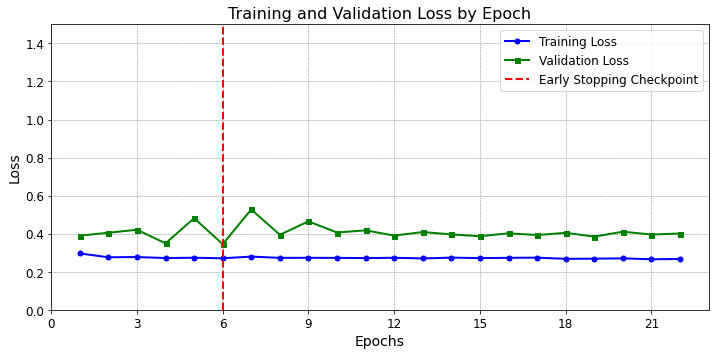

In [85]:
plot_losses(train_losses, valid_losses)

## Testing

### Load Best Model

In [86]:
model.load_state_dict(torch.load(path_checkpoints + file_name))

<All keys matched successfully>

### Test Loop

In [87]:
def test_model(model, dataloader):
    
    model.eval()    
    all_labels = []
    all_predictions = []
    
    test_progress_bar = tqdm(dataloader)

    for batch in test_progress_bar:

        inputs = {key: value.to(device) for key, value in batch.items() if key != 'label'}
        labels = batch['label'].to(device)

        with torch.no_grad():
            outputs = model(inputs)

        predictions = nn.Softmax(dim=1)(outputs)
        predictions = predictions.detach().cpu().numpy()
        predictions = predictions[:,1]

        labels = labels.detach().cpu().numpy()

        all_labels.extend(labels)
        all_predictions.extend(predictions)

    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)

    return all_labels, all_predictions

In [88]:
train_loader_no_sampler = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

In [89]:
test_true_labels , test_prediction_probs  = test_model(model, test_loader)
train_true_labels, train_prediction_probs = test_model(model, train_loader_no_sampler)
valid_true_labels, valid_prediction_probs = test_model(model, valid_loader)

  0%|          | 0/558 [00:00<?, ?it/s]

  0%|          | 0/2440 [00:00<?, ?it/s]

  0%|          | 0/230 [00:00<?, ?it/s]

### Calibration

In [90]:
def calibrate_probabilities(predicted_probabilities, true_labels):

    predicted_probabilities = np.asarray(predicted_probabilities)
    true_labels = np.asarray(true_labels)

    isotonic_regressor = IsotonicRegression(out_of_bounds='clip')
    isotonic_regressor.fit(predicted_probabilities, true_labels)

    calibrated_probabilities = isotonic_regressor.transform(predicted_probabilities)

    return isotonic_regressor

In [91]:
true_labels_tv = np.concatenate([train_true_labels, valid_true_labels], axis=0)
pred_probs_tv  = np.concatenate([train_prediction_probs,  valid_prediction_probs],  axis=0)

isotonic_regressor = calibrate_probabilities(pred_probs_tv, true_labels_tv)
# test_prediction_probs = isotonic_regressor.transform(test_prediction_probs)

### LLM Result

In [93]:
train_result['Predicted_Prob'] = train_prediction_probs 
train_result['Label'] = train_true_labels 

valid_result['Predicted_Prob'] = valid_prediction_probs 
valid_result['Label'] = valid_true_labels 

test_result['Predicted_Prob'] = test_prediction_probs 
test_result['Label'] = test_true_labels 

print(train_result[train_result.icu_expire_flag != train_result.Label].shape)
print(valid_result[valid_result.icu_expire_flag != valid_result.Label].shape)
print(test_result[test_result.icu_expire_flag   != test_result.Label].shape)

(0, 8)
(0, 8)
(0, 8)


### ROC

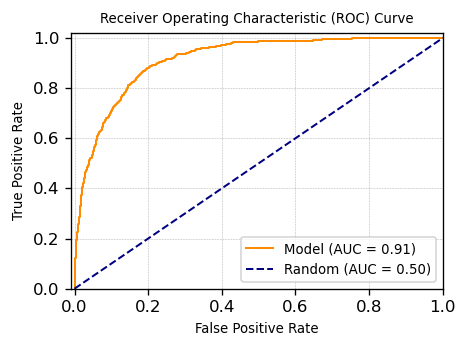

In [94]:
ROC_curve(test_result.icu_expire_flag, test_result.Predicted_Prob)

### Precision - Recall

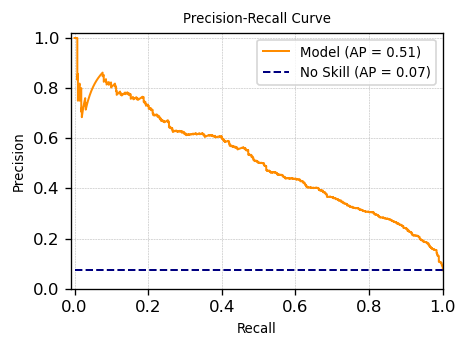

In [95]:
PRC_REC_curve(test_result.icu_expire_flag, test_result.Predicted_Prob)

### Set Decision Threshold

In [97]:
decision_recall = 0.8

In [98]:
predicted_label_lstm, decision_threshold_lstm = Prediction_Labels_Thresholding(test_result.icu_expire_flag, 
                                                                               test_result.Predicted_Prob, 
                                                                               decision_recall)

test_result['Predicted_Label'] = predicted_label_lstm

Decision Threshold is:  0.73


### Confusion Matrix

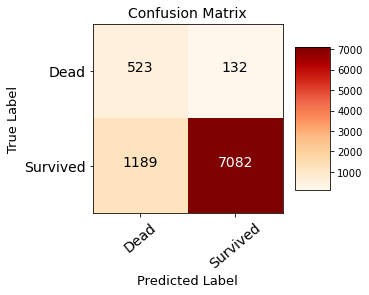

In [99]:
Confusion_Matrix(test_result.icu_expire_flag, test_result.Predicted_Label, classes = ['Dead', 'Survived'])

### Performance Metrics

In [100]:
Performance_Metrics(test_result.icu_expire_flag, test_result.Predicted_Label, test_result.Predicted_Prob)

ACC =  0.85
PRC =  0.31
REC =  0.8
F1M =  0.44
PPV =  0.31
NPV =  0.98
SEN =  0.8
SPE =  0.86
FPR =  0.14
FNR =  0.2
FDR =  0.69
AUC =  0.91
AP  =  0.51
MCC =  0.43


### Distribution of Prediction Probabilities

In [101]:
df_prediction_lstm_alive = test_result[test_result['ICU_FLAG'] == 'Survived']
df_prediction_lstm_dead  = test_result[test_result['ICU_FLAG'] == 'Dead']

### Alive Patients

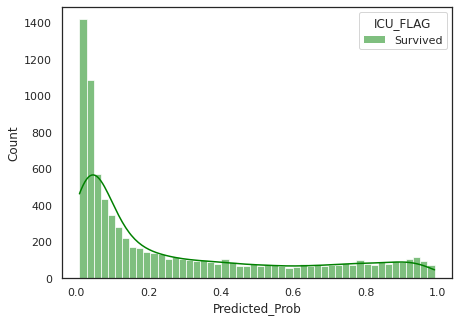

In [102]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_lstm_alive, x='Predicted_Prob', kde=True, stat='count', bins=50, fill=True,
             legend=True, hue='ICU_FLAG', palette=['green'])
plt.show()

### Dead Patients

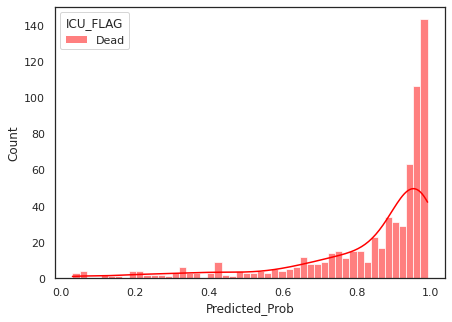

In [103]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_lstm_dead, x='Predicted_Prob', kde=True, stat='count', bins=50, fill=True,
             legend=True, hue='ICU_FLAG', palette=['red'])
plt.show()

### Multimodal

In [1408]:
# Binary_Classification_Performance(test_result.icu_expire_flag, test_result.Predicted_Prob, decision_threshold_lstm)

### Save Rsult

In [1409]:
# test_result.to_csv(f"./Results/EHR_Note_Comorbidity_Pooling_{fusion_type}_Result.csv", index=False)
# patients_result_df.to_csv("./Results/LSTM_LLM_FF_Result_Cal.csv", index=False)

In [96]:
# patients_result_df = pd.read_csv("./Results/LSTM_LLM_FF_Result_Cal.csv")

### Bias & Fairness

In [104]:
test_result.head(3)

### Read Race Dictionary

In [105]:
with open(race_path + 'race_dictionary.pkl', 'rb') as f:
    race_dictionary = pickle.load(f)

In [106]:
general_ethnicity_mapping = {
    
    'WHITE': 'White',
    'WHITE - RUSSIAN': 'White',
    'WHITE - BRAZILIAN': 'White',
    'WHITE - OTHER EUROPEAN': 'White',
    'WHITE - EASTERN EUROPEAN': 'White',
    'PORTUGUESE': 'White',
    
    'UNKNOWN': 'Other',
    'UNABLE TO OBTAIN': 'Other',
    'PATIENT DECLINED TO ANSWER': 'Other',
    
    'OTHER': 'Other',
    'MIDDLE EASTERN': 'Other',
    'MULTIPLE RACE/ETHNICITY': 'Other',
    'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'Other',
    
    'ASIAN': 'Asian',
    'ASIAN - CHINESE': 'Asian',
    'ASIAN - SOUTH EAST ASIAN': 'Asian',
    'ASIAN - KOREAN': 'Asian',
    'ASIAN - ASIAN INDIAN': 'Asian',
    
    'AMERICAN INDIAN/ALASKA NATIVE': 'Native American',
    
    'BLACK/AFRICAN': 'Black/African American',
    'BLACK/CAPE VERDEAN': 'Black/African American',
    'BLACK/AFRICAN AMERICAN': 'Black/African American',
    'BLACK/CARIBBEAN ISLAND': 'Black/African American',
    
    'SOUTH AMERICAN': 'Hispanic/Latino',
    'HISPANIC OR LATINO': 'Hispanic/Latino',
    'HISPANIC/LATINO - CUBAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - MEXICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - HONDURAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - COLUMBIAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - DOMINICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - SALVADORAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - GUATEMALAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - PUERTO RICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - CENTRAL AMERICAN': 'Hispanic/Latino'}

In [107]:
def replace_ethnicity_with_names(df, ethnicity_dict):
    
    inv_ethnicity_dict = {v: k for k, v in ethnicity_dict.items()}
    df['race'] = df['race'].map(inv_ethnicity_dict)
    
    return df

In [108]:
def categorize_ethnicity(df, new_mapping):
    
    df['race'] = df['race'].map(new_mapping)
    
    return df

In [109]:
demog_col = ['stay_id', 'gender', 'age', 'race']
df_demog = test_result[demog_col].copy()

df_demog = replace_ethnicity_with_names(df_demog, race_dictionary)
df_demog = categorize_ethnicity(df_demog, general_ethnicity_mapping)

df_demog = df_demog.drop_duplicates().reset_index(drop=True)
df_demog.loc[df_demog.gender == 1.0, 'gender'] = 'Male'
df_demog.loc[df_demog.gender == 2.0, 'gender'] = 'Female'

bins = [-np.inf, 35, 50, 60, 75, np.inf]
labels = ['Under 35', '36-50', '51-60', '61-75', 'Over 76']
df_demog['agegroup'] = pd.cut(df_demog['age'], bins=bins, labels=labels, right=False)
df_demog = df_demog.drop(columns= 'age')

In [110]:
df_demog.head(3)

### Multimodal Result Frame

In [111]:
MULTI_df_bias = test_result[['stay_id', 'Predicted_Label', 'icu_expire_flag']]
MULTI_df_bias = pd.merge(MULTI_df_bias, df_demog, on=['stay_id'], how='left')

MULTI_df_bias.rename(columns={'gender': 'sex',
                              'race' : 'ethnic',
                              'stay_id': 'entity_id',
                              'Predicted_Label': 'score', 
                              'icu_expire_flag': 'label_value'}, inplace=True)

MULTI_df_bias['sex']  = MULTI_df_bias.sex.astype(str)
MULTI_df_bias['score'] = MULTI_df_bias.score.astype(int)
MULTI_df_bias['ethnic'] = MULTI_df_bias.ethnic.astype(str)
MULTI_df_bias['agegroup'] = MULTI_df_bias.agegroup.astype(str)
MULTI_df_bias.head(3)

In [112]:
g = Group()

MULTItab, _ = g.get_crosstabs(MULTI_df_bias, attr_cols=['sex', 'agegroup', 'ethnic'])
MULTItab['model_id'] = 'EHR + Notes'
MULTItab.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev
0,EHR + Notes,binary 0/1,1712,sex,Female,0.838397,0.821549,0.839779,0.017135,0.703883,0.160221,0.178451,0.982865,0.296117,824,3093,0.481308,0.210365,580,53,3040,244,297,3620,3917,8926,0.075823
1,EHR + Notes,binary 0/1,1712,sex,Male,0.862647,0.779330,0.869060,0.019170,0.685811,0.130940,0.220670,0.980830,0.314189,888,4121,0.518692,0.177281,609,79,4042,279,358,4651,5009,8926,0.071471
2,EHR + Notes,binary 0/1,1712,agegroup,36-50,0.911085,0.764706,0.920245,0.015748,0.625000,0.079755,0.235294,0.984252,0.375000,104,762,0.060748,0.120092,65,12,750,39,51,815,866,8926,0.058891


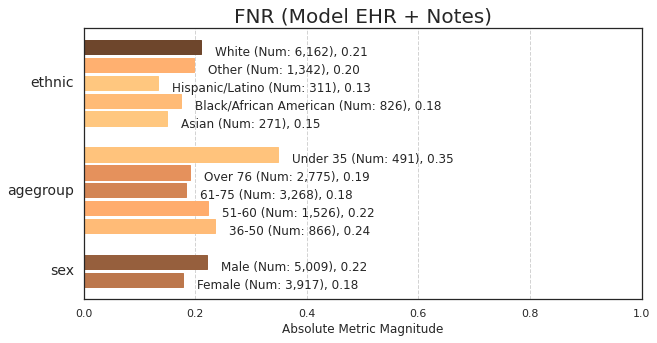

In [113]:
aqp = Plot()

a = aqp.plot_group_metric(MULTItab, 'fnr', min_group_size=0.01)

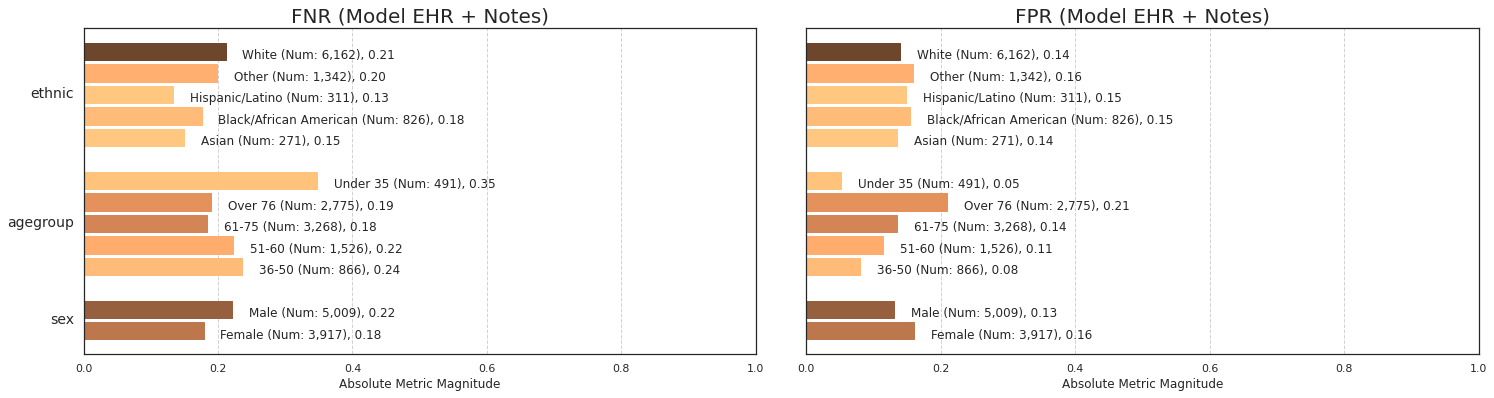

<Figure size 432x288 with 0 Axes>

In [114]:
a = aqp.plot_group_metric_all(MULTItab, metrics=['fnr','fpr'], ncols=2, min_group_size=0.01)

In [115]:
b = Bias()

sex_ref = 'Male' 
age_ref = '61-75'
ethnic_ref = 'White'

In [116]:
bdf = b.get_disparity_predefined_groups(MULTItab, original_df=MULTI_df_bias, alpha=0.05, mask_significance=True,
                                        ref_groups_dict={'ethnic':ethnic_ref,'sex':sex_ref,'agegroup':age_ref})
majority_bdf = b.get_disparity_major_group(MULTItab, original_df=MULTI_df_bias, mask_significance=True)
min_metric_bdf = b.get_disparity_min_metric(df=MULTItab, original_df=MULTI_df_bias)
bdf.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev,ppr_disparity,pprev_disparity,precision_disparity,fdr_disparity,for_disparity,fpr_disparity,fnr_disparity,tpr_disparity,tnr_disparity,npv_disparity,ppr_ref_group_value,pprev_ref_group_value,precision_ref_group_value,fdr_ref_group_value,for_ref_group_value,fpr_ref_group_value,fnr_ref_group_value,tpr_ref_group_value,tnr_ref_group_value,npv_ref_group_value
0,EHR + Notes,binary 0/1,1712,sex,Female,0.838397,0.821549,0.839779,0.017135,0.703883,0.160221,0.178451,0.982865,0.296117,824,3093,0.481308,0.210365,580,53,3040,244,297,3620,3917,8926,0.075823,0.927928,1.186620,0.942478,1.026352,0.893864,1.223625,0.808677,1.054174,0.966307,1.002074,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
1,EHR + Notes,binary 0/1,1712,sex,Male,0.862647,0.779330,0.869060,0.019170,0.685811,0.130940,0.220670,0.980830,0.314189,888,4121,0.518692,0.177281,609,79,4042,279,358,4651,5009,8926,0.071471,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
2,EHR + Notes,binary 0/1,1712,agegroup,36-50,0.911085,0.764706,0.920245,0.015748,0.625000,0.079755,0.235294,0.984252,0.375000,104,762,0.060748,0.120092,65,12,750,39,51,815,866,8926,0.058891,0.178388,0.673176,1.293639,0.880133,1.112723,0.589683,1.281734,0.936652,1.064175,0.998382,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75


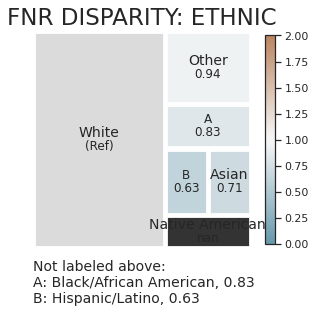

In [117]:
aqp.plot_disparity(majority_bdf, group_metric='fnr_disparity', attribute_name='ethnic', significance_alpha=0.05)

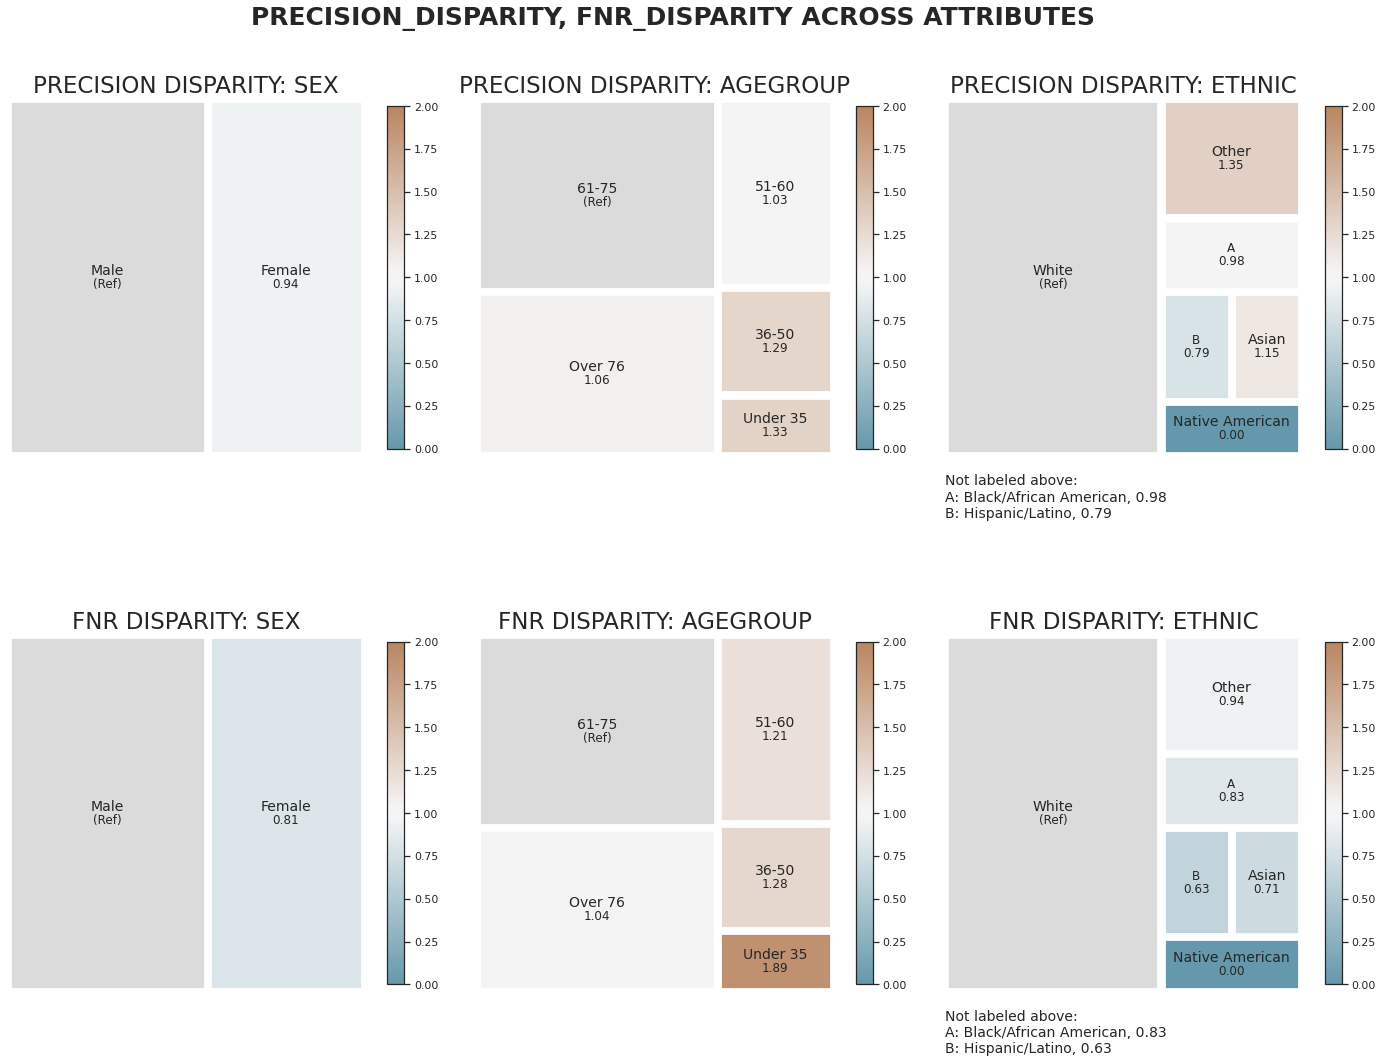

In [118]:
a = aqp.plot_disparity_all(majority_bdf, metrics=['precision_disparity', 'fnr_disparity'], significance_alpha=0.05)

In [119]:
f = Fairness()

fdf = f.get_group_value_fairness(bdf)
gaf = f.get_group_attribute_fairness(fdf)
fdf.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev,ppr_disparity,pprev_disparity,precision_disparity,fdr_disparity,for_disparity,fpr_disparity,fnr_disparity,tpr_disparity,tnr_disparity,npv_disparity,ppr_ref_group_value,pprev_ref_group_value,precision_ref_group_value,fdr_ref_group_value,for_ref_group_value,fpr_ref_group_value,fnr_ref_group_value,tpr_ref_group_value,tnr_ref_group_value,npv_ref_group_value,Statistical Parity,Impact Parity,FDR Parity,FPR Parity,FOR Parity,FNR Parity,TPR Parity,TNR Parity,NPV Parity,Precision Parity,TypeI Parity,TypeII Parity,Equalized Odds,Unsupervised Fairness,Supervised Fairness
0,EHR + Notes,binary 0/1,1712,sex,Female,0.838397,0.821549,0.839779,0.017135,0.703883,0.160221,0.178451,0.982865,0.296117,824,3093,0.481308,0.210365,580,53,3040,244,297,3620,3917,8926,0.075823,0.927928,1.186620,0.942478,1.026352,0.893864,1.223625,0.808677,1.054174,0.966307,1.002074,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1,EHR + Notes,binary 0/1,1712,sex,Male,0.862647,0.779330,0.869060,0.019170,0.685811,0.130940,0.220670,0.980830,0.314189,888,4121,0.518692,0.177281,609,79,4042,279,358,4651,5009,8926,0.071471,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,EHR + Notes,binary 0/1,1712,agegroup,36-50,0.911085,0.764706,0.920245,0.015748,0.625000,0.079755,0.235294,0.984252,0.375000,104,762,0.060748,0.120092,65,12,750,39,51,815,866,8926,0.058891,0.178388,0.673176,1.293639,0.880133,1.112723,0.589683,1.281734,0.936652,1.064175,0.998382,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75,False,False,True,False,True,False,True,True,True,False,False,False,False,False,False


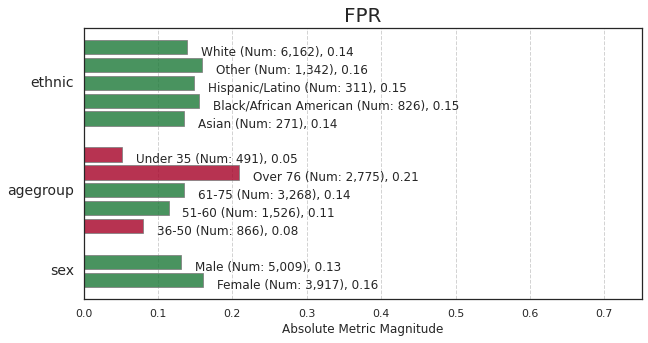

In [124]:
a = aqp.plot_fairness_group(fdf, group_metric='fpr', min_group_size=0.01, ax_lim=0.75, title=True)

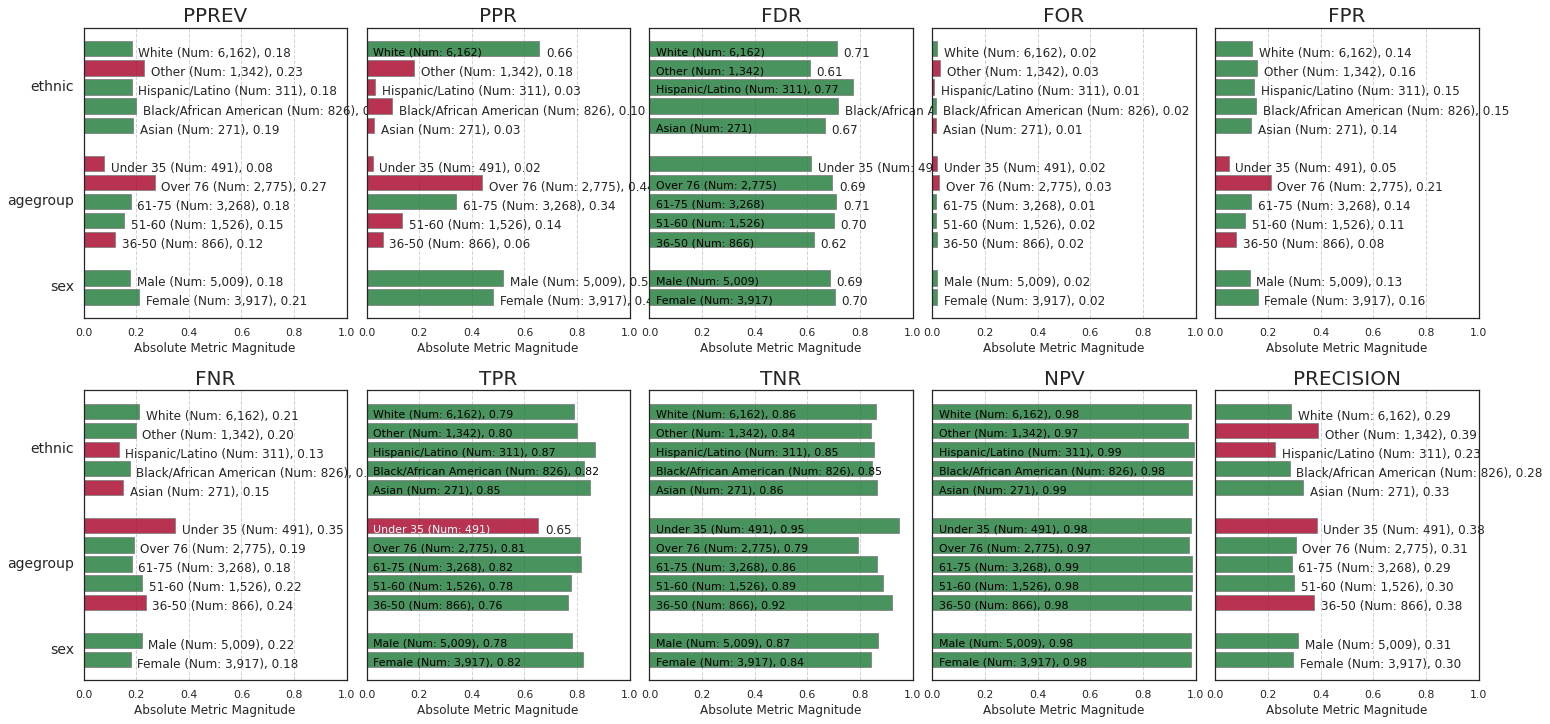

<Figure size 432x288 with 0 Axes>

In [121]:
a = aqp.plot_fairness_group_all(fdf, ncols=5, metrics = "all", min_group_size=0.01)

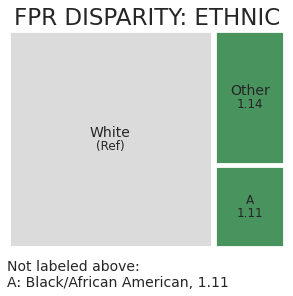

In [122]:
a = aqp.plot_fairness_disparity(fdf, group_metric='fpr', attribute_name='ethnic', min_group_size=0.02, significance_alpha=0.05)

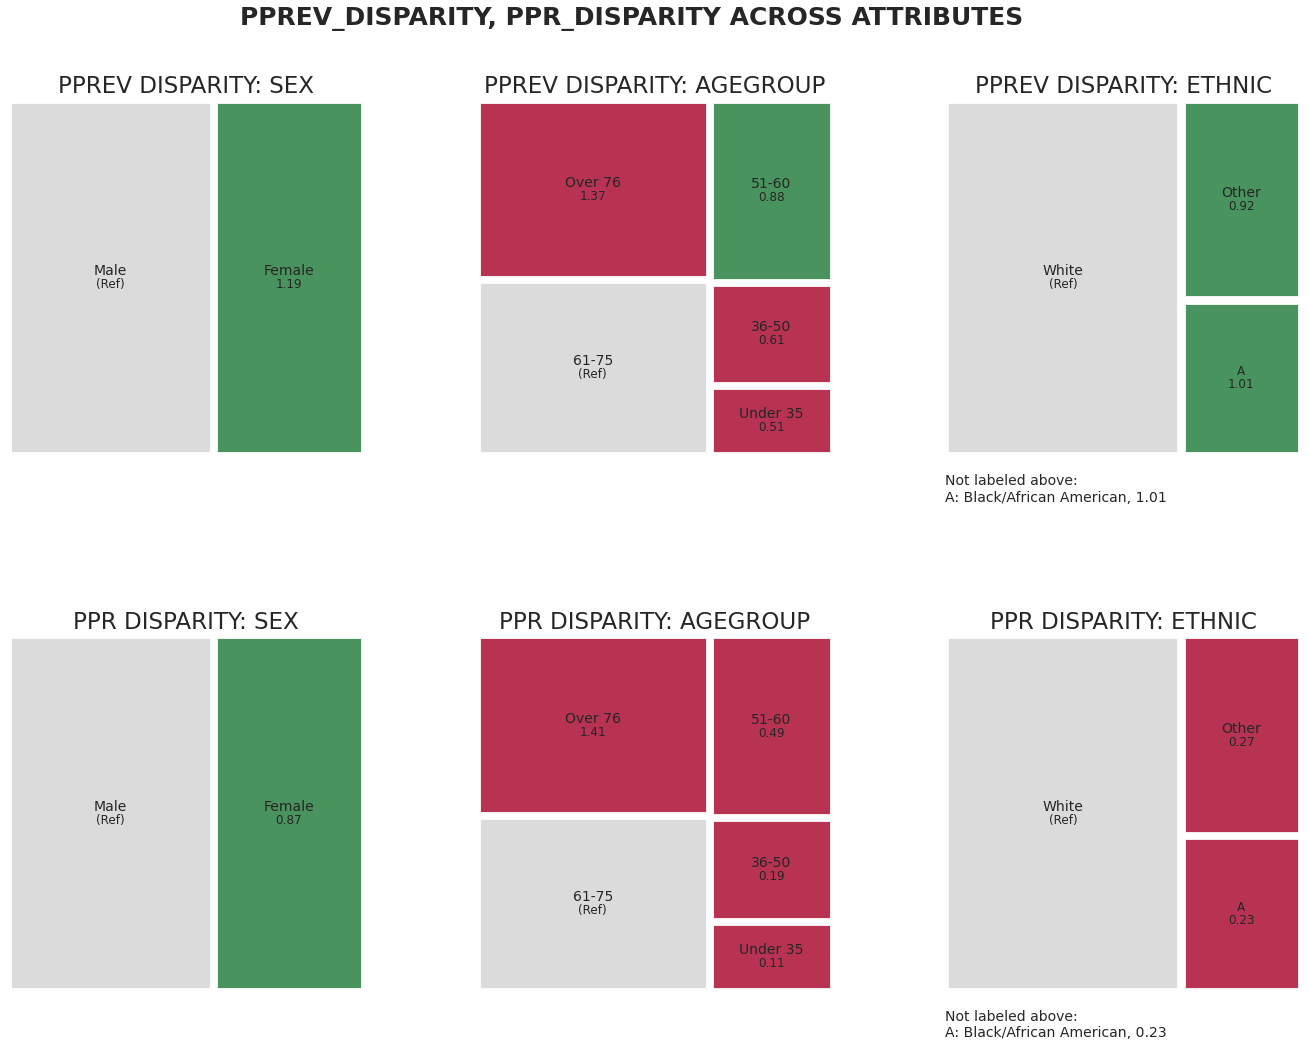

In [305]:
a = aqp.plot_fairness_disparity_all(fdf, metrics=['pprev_disparity', 'ppr_disparity'],  min_group_size=0.02, significance_alpha=0.05)